# Capping Machine Data Analytics

This notebook analyses synthetic data from a multi-head capping machine. I use the raw polling data to build an event-level dataset and then look at production performance, quality and machine behaviour.

The main workflow is **clean → validate → calculate KPIs → investigate quality → analyse trends → compare heads → summarise findings**.

In [1]:
import os
import sys
from pathlib import Path

# Make the notebook work whether it's opened from the notebooks/ folder
# or from the project root, and without needing an editable pip install.
if Path.cwd().name == "notebooks":
    os.chdir("..")
if str(Path("src").resolve()) not in sys.path:
    sys.path.insert(0, str(Path("src").resolve()))

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

from capping_telemetry.config import load_config
from capping_telemetry.ingestion.loader import load_pool_streaming, validate_pool_files
from capping_telemetry.analytics import kpi, anomaly, trend, idle, correlation, filters

settings = load_config(None)

## 1. Data quality and event reconstruction

The raw export is a polling stream, so a single capping cycle can appear in several rows. I first validate the file and then use the per-head counter to keep only rows where a new closure actually happened.

In [2]:
issues = validate_pool_files(settings, pool_name="sample_pool")

print("Data quality checks:")
print("No issues found." if not issues else "\n".join(issues))

Data quality checks:
No issues found.


In [3]:
events, idle_periods, meta = load_pool_streaming(settings, pool_name="sample_pool")

print(f"Polling rows checked: {meta.get('total_raw_rows', 0):,}")
print(f"Closure events detected: {len(events):,}")
print(f"Heads represented: {events['head_id'].nunique()}")
print(f"Quality issues: {len(meta.get('quality_issues', []))}")

events.head(10)

Polling rows checked: 86,400
Closure events detected: 1,007,653
Heads represented: 36
Quality issues: 0


,event_timestamp,head_id,torque,status,success,is_no_load,is_reject,is_fault,status_category,status_description,count,count_seq_gap
0,2026-04-01 06:00:01+00:00,H14,0.00,2,False,True,False,False,no_load,No Load,21782,1
1,2026-04-01 06:00:01+00:00,H35,2.20,0,True,False,False,False,success,Closure OK,24659,1
2,2026-04-01 06:00:01+00:00,H08,0.00,2,False,True,False,False,no_load,No Load,20960,1
3,2026-04-01 06:00:01+00:00,H09,2.40,0,True,False,False,False,success,Closure OK,21097,1
4,2026-04-01 06:00:01+00:00,H28,0.00,2,False,True,False,False,no_load,No Load,23700,1
5,2026-04-01 06:00:01+00:00,H10,0.00,2,False,True,False,False,no_load,No Load,21234,1
6,2026-04-01 06:00:01+00:00,H11,2.59,0,True,False,False,False,success,Closure OK,21371,1
7,2026-04-01 06:00:01+00:00,H13,0.00,2,False,True,False,False,no_load,No Load,21645,1
8,2026-04-01 06:00:01+00:00,H23,2.23,0,True,False,False,False,success,Closure OK,23015,1
9,2026-04-01 06:00:01+00:00,H12,0.00,2,False,True,False,False,no_load,No Load,21508,1


In [4]:
event_summary = (
    events["status_category"]
    .value_counts()
    .rename_axis("status_category")
    .reset_index(name="events")
)
event_summary

,status_category,events
0,no_load,802704
1,success,186284
2,reject,13179
3,fault,5486


## 2. Production KPIs

For quality KPIs, I exclude `no_load` cycles from the denominator because those are not real capping attempts. I keep rejects and faults separate so the result is more useful than simply calling every non-success event a failure.

In [5]:
overall = pd.Series(kpi.overall_success_rate(events), name="value")
overall.to_frame()

,value
total_closures,"1,007,653.00"
no_load,"802,704.00"
attempted,"204,949.00"
successful,"186,284.00"
rejected,"13,179.00"
faults,"5,486.00"
success_rate_pct,90.90
reject_rate_pct,6.40


In [6]:
head_kpis = kpi.success_rate_per_head(events)
head_kpis

,head_id,total_closures,no_load,attempted,successful,rejected,success_rate_pct
2,H03,28687,23990,4697,3515,952,74.80
29,H30,28911,24233,4678,3960,548,84.70
4,H05,28616,23469,5147,4466,544,86.80
24,H25,27621,23039,4582,3987,506,87.00
8,H09,27522,22553,4969,4341,474,87.40
16,H17,26728,20825,5903,5166,533,87.50
12,H13,28408,22933,5475,4802,484,87.70
1,H02,29396,23939,5457,4804,472,88.00
18,H19,26747,20430,6317,5576,501,88.30
0,H01,28154,23322,4832,4279,457,88.60


In [7]:
torque_kpis = kpi.torque_statistics_per_head(events)
torque_kpis.sort_values("mean_nm")

,head_id,n_events,mean_nm,min_nm,max_nm,std_nm
22,H23,4370,2.08,1.53,2.73,0.16
15,H16,5178,2.17,1.55,2.77,0.18
2,H03,3515,2.23,1.93,2.56,0.09
26,H27,6151,2.28,1.44,3.11,0.23
0,H01,4279,2.34,1.77,2.81,0.14
34,H35,4316,2.34,1.94,2.72,0.11
25,H26,5333,2.37,1.96,2.81,0.12
31,H32,6531,2.40,1.94,2.73,0.09
17,H18,6485,2.43,2.07,2.75,0.10
27,H28,5339,2.43,1.93,2.88,0.13


In [8]:
comparison = kpi.failed_vs_successful_torque(events)
pd.DataFrame({
    "successful": comparison["successful"],
    "rejected": comparison["rejected"],
}).T

,n_events,mean_nm,min_nm,max_nm,std_nm
successful,"186,284.00",2.47,1.44,3.25,0.17
rejected,"13,179.00",1.47,0.75,2.02,0.14


### Head performance

A useful first check is whether a small number of heads are responsible for most quality problems. I compare reject counts with the success-rate table rather than relying on one overall average.

In [9]:
lowest_success_heads = head_kpis.sort_values("success_rate_pct").head(8)
lowest_success_heads[["head_id", "attempted", "successful", "rejected", "success_rate_pct"]]

,head_id,attempted,successful,rejected,success_rate_pct
2,H03,4697,3515,952,74.80
29,H30,4678,3960,548,84.70
4,H05,5147,4466,544,86.80
24,H25,4582,3987,506,87.00
8,H09,4969,4341,474,87.40
16,H17,5903,5166,533,87.50
12,H13,5475,4802,484,87.70
1,H02,5457,4804,472,88.00


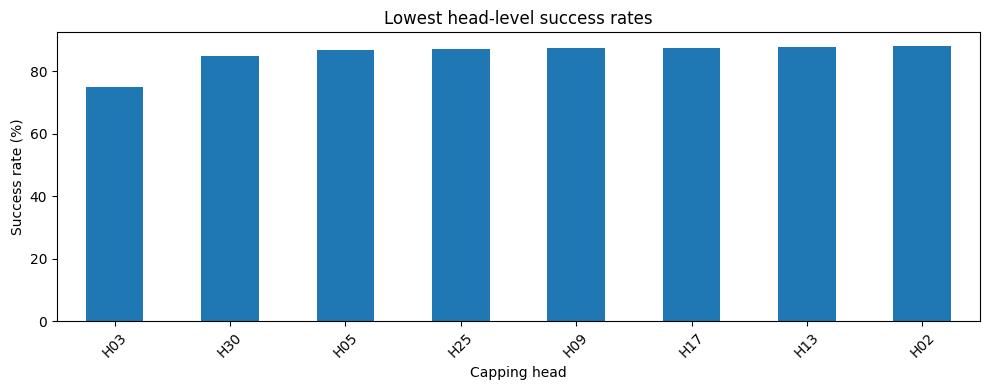

In [10]:
ax = lowest_success_heads.set_index("head_id")["success_rate_pct"].plot(kind="bar", figsize=(10, 4))
ax.set_title("Lowest head-level success rates")
ax.set_ylabel("Success rate (%)")
ax.set_xlabel("Capping head")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()


## 3. Torque and quality analysis

Torque is a key process variable for a capping machine. I look at both fixed operating limits and statistical outliers because those answer slightly different questions.

In [11]:
range_issues = anomaly.out_of_range_torque(events, settings)
print(f"Successful closure events outside the configured torque range: {len(range_issues):,}")
range_issues.head(15)

Successful closure events outside the configured torque range: 7,357


,event_timestamp,head_id,torque,status,success
159,2026-04-01 06:00:13+00:00,H13,1.41,5,False
265,2026-04-01 06:00:22+00:00,H19,1.42,65,False
345,2026-04-01 06:00:30+00:00,H22,1.41,33,False
366,2026-04-01 06:00:31+00:00,H28,1.42,65,False
370,2026-04-01 06:00:32+00:00,H26,1.38,17,False
679,2026-04-01 06:00:58+00:00,H04,1.45,33,False
701,2026-04-01 06:01:00+00:00,H16,1.49,3,False
782,2026-04-01 06:01:07+00:00,H01,1.27,33,False
856,2026-04-01 06:01:13+00:00,H19,1.37,65,False
858,2026-04-01 06:01:14+00:00,H27,1.34,5,False


In [12]:
outliers = anomaly.statistical_outliers(events)
print(f"Statistical torque outliers: {len(outliers):,}")
outliers[["event_timestamp", "head_id", "torque", "status_category", "torque_zscore"]].head(15)

Statistical torque outliers: 524


,event_timestamp,head_id,torque,status_category,torque_zscore
897239,2026-04-02 03:22:14+00:00,H02,3.25,success,5.04
210162,2026-04-01 11:00:23+00:00,H14,2.99,success,4.95
976437,2026-04-02 05:15:22+00:00,H32,1.94,success,-4.85
850597,2026-04-02 02:15:32+00:00,H24,3.09,success,4.81
664105,2026-04-01 21:49:00+00:00,H15,1.93,success,-4.80
792950,2026-04-02 00:53:09+00:00,H36,3.15,success,4.64
663259,2026-04-01 21:47:48+00:00,H24,3.05,success,4.47
446985,2026-04-01 16:38:47+00:00,H04,3.20,success,4.46
190210,2026-04-01 10:31:53+00:00,H33,3.19,success,4.41
28512,2026-04-01 06:40:46+00:00,H24,2.03,success,-4.28


In [13]:
faults = pd.DataFrame(anomaly.fault_code_breakdown(events))
faults

,status,status_description,is_reject,count
0,65,ClosureTorque reached but cap is still rotatin...,True,2238
1,9,Closure Head raises before the TimeInTorque ti...,True,2216
2,5,Failing to reach the final torque (ClosureTorque),True,2204
3,3,Failing to reach the first torque threshold (S...,True,2199
4,17,The cap is closed but with less degrees than C...,True,2176
5,33,Tracking error between the real position and t...,True,2146
6,4,No Closure,False,1150
7,16,No CapTurns,False,1112
8,64,Bad Closure,False,1090
9,8,No InTorque,False,1075


In [14]:
consistency = anomaly.torque_status_consistency_check(events)
pd.Series(consistency, name="value").to_frame()

,value
no_load_with_nonzero_torque_count,0
zero_torque_not_marked_no_load_count,0
note,Both counts should normally be near zero. Non-...


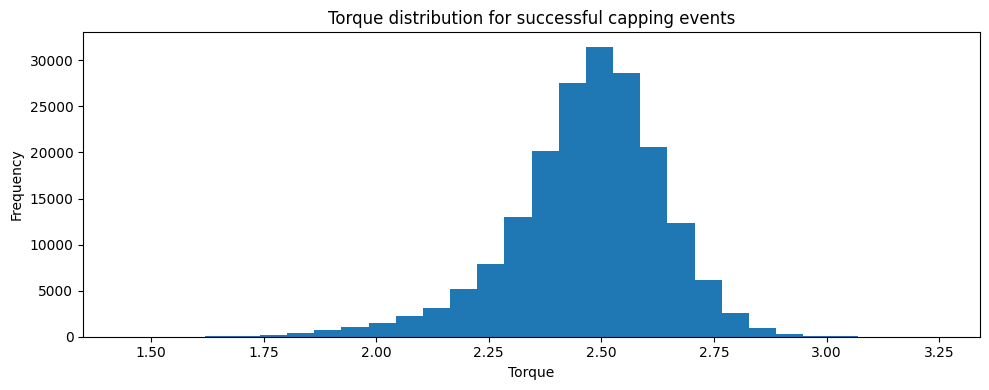

In [15]:
successful = events[events["success"]].copy()

ax = successful["torque"].plot(kind="hist", bins=30, figsize=(10, 4))
ax.set_title("Torque distribution for successful capping events")
ax.set_xlabel("Torque")
plt.tight_layout()
plt.show()
plt.close()


## 4. Trends, throughput and drift

Looking only at an overall average can hide a gradual change. I use a rolling average and compare the first and second parts of the observed period for each head.

In [16]:
drift = trend.detect_drift(events, settings)
drift.sort_values("zscore", key=abs, ascending=False).head(10)

,head_id,baseline_mean_nm,recent_mean_nm,zscore,drift_detected
0,H01,2.34,2.34,-0.05,False
12,H13,2.51,2.51,0.05,False
16,H17,2.53,2.53,0.05,False
15,H16,2.17,2.18,0.05,False
30,H31,2.51,2.52,0.05,False
21,H22,2.45,2.44,-0.04,False
1,H02,2.57,2.57,-0.03,False
23,H24,2.53,2.53,-0.03,False
19,H20,2.52,2.52,0.03,False
6,H07,2.56,2.56,-0.03,False


In [17]:
daily_quality = trend.success_rate_over_time(events)
daily_quality

,period,attempted,successful,rejected,success_rate_pct
0,2026-04-01 00:00:00+00:00,153832,139854,9844,90.90
1,2026-04-02 00:00:00+00:00,51117,46430,3335,90.80


In [18]:
hourly_quality = trend.success_rate_by_hour_of_day(events)
hourly_quality

,hour,attempted,successful,rejected,success_rate_pct
0,0,8445,7649,564,90.60
1,1,8534,7736,575,90.60
2,2,8560,7759,580,90.60
3,3,8527,7807,507,91.60
4,4,8552,7750,551,90.60
5,5,8499,7729,558,90.90
6,6,8376,7615,530,90.90
7,7,8514,7712,551,90.60
8,8,8575,7770,560,90.60
9,9,8544,7755,567,90.80


In [19]:
speed = trend.capping_speed_over_time(events)
speed

,period,n_events,pieces_per_hour
0,2026-04-01 00:00:00+00:00,755769,"41,988.50"
1,2026-04-02 00:00:00+00:00,251884,"41,982.60"


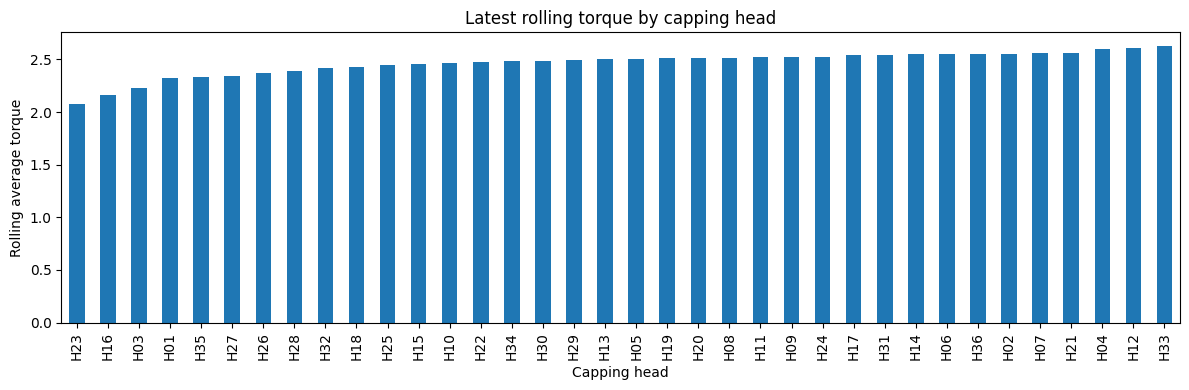

In [20]:
moving_avg = trend.torque_moving_average(events, settings)

ax = moving_avg.groupby("head_id").tail(1).sort_values("torque_moving_avg").plot(
    x="head_id", y="torque_moving_avg", kind="bar", figsize=(12, 4), legend=False
)
ax.set_title("Latest rolling torque by capping head")
ax.set_xlabel("Capping head")
ax.set_ylabel("Rolling average torque")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.close()


## 5. Idle and no-load behaviour

No-load activity is not a quality failure, but a high amount of it can reduce effective production time. The idle calculation also handles periods that continue across input-file boundaries.

In [21]:
if idle_periods.empty:
    print("No idle periods met the configured duration threshold.")
else:
    idle_summary = (
        idle_periods.groupby("head_id")
        .agg(idle_periods=("duration_s", "size"), idle_seconds=("duration_s", "sum"))
        .sort_values("idle_seconds", ascending=False)
    )
    idle_summary.head(10)

## 6. Relationships between process variables and quality

Correlation is only a screening tool here, not proof that torque causes a reject. It is useful for finding heads or operating conditions that deserve a closer look.

In [22]:
torque_success_corr = correlation.torque_vs_success_correlation(events)
pd.Series(torque_success_corr, name="value").to_frame()

,value
correlation,0.68
n_events,"204,949.00"


In [23]:
deviation = correlation.rank_heads_by_deviation(events)
deviation.head(10)

,head_id,mean_torque_nm,success_rate_pct,deviation_score
2,H03,2.05,74.84,6.73
22,H23,2.04,91.85,3.08
15,H16,2.13,93.86,2.89
26,H27,2.25,94.18,2.02
20,H21,2.49,95.75,1.99
13,H14,2.51,94.59,1.89
32,H33,2.57,92.15,1.72
11,H12,2.52,93.65,1.71
0,H01,2.25,88.56,1.67
28,H29,2.48,94.85,1.66


In [24]:
pair_corr = correlation.torque_correlation_between_heads(events, "H01", "H02", settings)
pd.Series(pair_corr, name="value").to_frame()

,value
head_a,H01
head_b,H02
n_pairs,4832
correlation,-0.00


## 7. Useful event-level drill-down

After the aggregated analysis, I can filter the clean event table to inspect the individual rejects that drive the KPI.

In [25]:
rejects = filters.list_closure_events(
    events,
    status_category="reject",
    torque_max=settings.analytics.torque_expected_range_nm[1],
)
rejects.head(20)

,event_timestamp,head_id,torque,status_category,status_description
0,2026-04-01 06:00:01+00:00,H02,1.58,reject,Tracking error between the real position and t...
1,2026-04-01 06:00:08+00:00,H30,1.50,reject,Failing to reach the first torque threshold (S...
2,2026-04-01 06:00:11+00:00,H15,1.52,reject,ClosureTorque reached but cap is still rotatin...
3,2026-04-01 06:00:13+00:00,H13,1.41,reject,Failing to reach the final torque (ClosureTorque)
4,2026-04-01 06:00:22+00:00,H19,1.42,reject,ClosureTorque reached but cap is still rotatin...
5,2026-04-01 06:00:30+00:00,H22,1.41,reject,Tracking error between the real position and t...
6,2026-04-01 06:00:31+00:00,H28,1.42,reject,ClosureTorque reached but cap is still rotatin...
7,2026-04-01 06:00:32+00:00,H26,1.38,reject,The cap is closed but with less degrees than C...
8,2026-04-01 06:00:42+00:00,H09,1.54,reject,Tracking error between the real position and t...
9,2026-04-01 06:00:46+00:00,H13,1.53,reject,Tracking error between the real position and t...


## 8. Analytical summary

The tables above provide the evidence for a short management-style summary. In a real project I would use the same structure to explain which heads have the weakest quality performance, whether torque behaviour is changing, and whether idle/no-load time is large enough to affect throughput.

The important part is that the conclusions are based on reconstructed capping events rather than raw polling rows.

In [26]:
summary = {
    "success_rate_pct": overall["success_rate_pct"],
    "reject_rate_pct": overall["reject_rate_pct"],
    "capping_speed_pieces_per_hour": trend.capping_speed_summary(events)["overall_pieces_per_hour"],
    "heads_with_drift_flag": int(drift["drift_detected"].sum()) if not drift.empty else 0,
    "torque_outliers": len(outliers),
    "idle_periods_found": len(idle_periods),
}

pd.Series(summary, name="result").to_frame()

,result
success_rate_pct,90.90
reject_rate_pct,6.40
capping_speed_pieces_per_hour,"41,986.50"
heads_with_drift_flag,0.00
torque_outliers,524.00
idle_periods_found,48.00
